
Stage 0

Steady-state summary (mean +/- SD):
           sd_radius         lane_count           overlaps        
                mean     std       mean     std       mean     std
population                                                        
450           0.6195  0.0118     1.2198  0.1861   393.1604  1.1092
1050          0.6213  0.0161     1.1881  0.2001  1016.7406  1.5774
2050          0.6100  0.0036     1.1406  0.1172  2027.1347  0.7881
3050          0.6213  0.0066     1.2317  0.1335  3031.5010  0.6467
4050          0.6183  0.0060     1.1446  0.0943  4033.4594  0.8892
4950          0.6115  0.0029     1.1505  0.0895  4934.0099  0.3460

--- Stage 0 | sd_radius ---
Shapiro-Wilk normality per group:
  population=450: W=0.874, p=0.2842, n=5
  population=1050: W=0.882, p=0.3177, n=5
  population=2050: W=0.881, p=0.3119, n=5
  population=3050: W=0.747, p=0.0281, n=5  <-- below .05
  population=4050: W=0.795, p=0.0733, n=5
  population=4950: W=0.732, p=0.0200, n=5  <-- below .05
Levene'

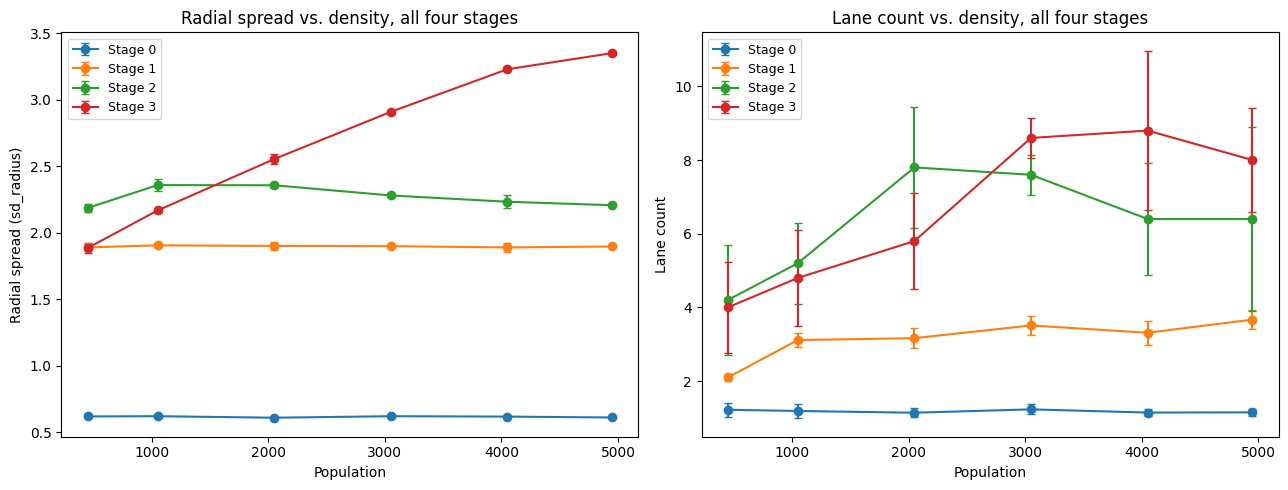

In [3]:
"""
Tawaf Ablation Analysis — All Four Stages (0, 1, 2, 3)
========================================================
Full statistical analysis (assumption checks, one-way ANOVA, Tukey HSD
post-hoc) and comparison figure for all four ablation stages, each
measured across the same six population levels with the same set of
metrics.
"""

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------

STAGE_FILES = {
    "Stage 0": "/content/Tawaf_Ablation_Model ablation_stage0_full_density_sweep-table.csv",
    "Stage 1": "/content/Tawaf_Ablation_Model ablation_stage1_full_density_sweep-table.csv",
    "Stage 2": "/content/Tawaf_Ablation_Model ablation_stage2_full_density_sweep-table.csv",
    "Stage 3": "/content/Tawaf_Ablation_Model ablation_stage3_full_density_sweep-table.csv",
}


STEADY_STATE_START = 100
STEADY_STATE_END = 200
ALPHA = 0.05


# ----------------------------------------------------------------------
# LOADING + STEADY-STATE COMPUTATION
# ----------------------------------------------------------------------

def load_behaviorspace_csv(path):
    df = pd.read_csv(path, skiprows=6)
    df.columns = [c.strip() for c in df.columns]
    return df.rename(columns={
        "lane-count 0.5 3": "lane_count",
        "sd-radius": "sd_radius",
        "edge-fraction 0.5": "edge_frac",
        "mean-nn": "mean_nn",
        "mean-speed": "mean_speed",
        "mean-local-density": "mean_density",
    })


def compute_per_run(df):
    n_steps_per_run = df.groupby(["population", "[run number]"])["[step]"].nunique()
    has_time_series = (n_steps_per_run > 1).any()

    if has_time_series:
        ss = df[(df["[step]"] >= STEADY_STATE_START) & (df["[step]"] <= STEADY_STATE_END)].copy()
    else:
        ss = df.copy()  # single final-tick snapshot per run

    agg_cols = {}
    for col in ["sd_radius", "lane_count", "overlaps", "mean_nn", "edge_frac", "mean_speed"]:
        if col in ss.columns:
            agg_cols[col] = (col, "mean")

    per_run = ss.groupby(["population", "[run number]"]).agg(**agg_cols).reset_index()
    return per_run


# ----------------------------------------------------------------------
# STATISTICAL ANALYSIS FOR ONE STAGE, ONE METRIC
# ----------------------------------------------------------------------

def analyze_metric(per_run, metric, stage_name):
    pops = sorted(per_run["population"].unique())
    groups = [per_run[per_run["population"] == p][metric].dropna().values for p in pops]

    print(f"\n--- {stage_name} | {metric} ---")

    print("Shapiro-Wilk normality per group:")
    for p, g in zip(pops, groups):
        if len(g) >= 3:
            w, sp = stats.shapiro(g)
            flag = "  <-- below .05" if sp < ALPHA else ""
            print(f"  population={p}: W={w:.3f}, p={sp:.4f}, n={len(g)}{flag}")

    lev_stat, lev_p = stats.levene(*groups)
    print(f"Levene's test: stat={lev_stat:.3f}, p={lev_p:.4f}")

    f_stat, p_val = stats.f_oneway(*groups)
    dfb = len(pops) - 1
    dfw = len(per_run) - len(pops)
    eta2 = (f_stat * dfb) / (f_stat * dfb + dfw) if (f_stat * dfb + dfw) != 0 else float("nan")
    sig = "SIGNIFICANT" if p_val < ALPHA else "not significant"
    print(f"ANOVA: F({dfb},{dfw}) = {f_stat:.2f}, p = {p_val:.2e}, eta^2 = {eta2:.3f}  [{sig}]")

    tukey = pairwise_tukeyhsd(endog=per_run[metric], groups=per_run["population"], alpha=ALPHA)
    print("Tukey HSD pairwise comparisons:")
    print(tukey.summary())

    return {"stage": stage_name, "metric": metric, "f_stat": f_stat,
            "p_val": p_val, "eta2": eta2, "levene_p": lev_p}


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------

def main():
    all_per_run = {}
    all_results = []

    for stage_name, filename in STAGE_FILES.items():
        print("\n" + "=" * 70)
        print(stage_name)
        print("=" * 70)

        df = load_behaviorspace_csv(filename)
        per_run = compute_per_run(df)
        all_per_run[stage_name] = per_run

        summary_cols = [c for c in ["sd_radius", "lane_count", "overlaps"] if c in per_run.columns]
        print(f"\nSteady-state summary (mean +/- SD):")
        print(per_run.groupby("population")[summary_cols].agg(["mean", "std"]).round(4))

        for metric in ["sd_radius", "lane_count"]:
            if metric in per_run.columns:
                result = analyze_metric(per_run, metric, stage_name)
                all_results.append(result)

        per_run.to_csv(f"{stage_name.replace(' ', '_')}_per_run.csv", index=False)

    # Print a compact cross-stage summary table
    print("\n" + "=" * 70)
    print("CROSS-STAGE ANOVA SUMMARY")
    print("=" * 70)
    summary_df = pd.DataFrame(all_results)
    print(summary_df[["stage", "metric", "f_stat", "p_val", "eta2"]].to_string(index=False))
    summary_df.to_csv("cross_stage_anova_summary.csv", index=False)

    # ------------------------------------------------------------------
    # COMPARISON FIGURE
    # ------------------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    for (stage_name, per_run), color in zip(all_per_run.items(), colors):
        means = per_run.groupby("population")["sd_radius"].mean()
        stds = per_run.groupby("population")["sd_radius"].std()
        axes[0].errorbar(means.index, means.values, yerr=stds.values, marker="o",
                          capsize=3, label=stage_name, color=color)
    axes[0].set_xlabel("Population")
    axes[0].set_ylabel("Radial spread (sd_radius)")
    axes[0].set_title("Radial spread vs. density, all four stages")
    axes[0].legend(fontsize=9)

    for (stage_name, per_run), color in zip(all_per_run.items(), colors):
        if "lane_count" not in per_run.columns:
            continue
        means = per_run.groupby("population")["lane_count"].mean()
        stds = per_run.groupby("population")["lane_count"].std()
        axes[1].errorbar(means.index, means.values, yerr=stds.values, marker="o",
                          capsize=3, label=stage_name, color=color)
    axes[1].set_xlabel("Population")
    axes[1].set_ylabel("Lane count")
    axes[1].set_title("Lane count vs. density, all four stages")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("four_stage_comparison.png", dpi=150)
    print("\nSaved comparison figure -> four_stage_comparison.png")
    print("Saved per-stage CSVs and cross_stage_anova_summary.csv")


if __name__ == "__main__":
    main()